In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# STEP 1: Dataset load karna
# ---------------------------------------------------
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Train shape:", train_images.shape)   # (60000, 28, 28)
print("Test shape:", test_images.shape)     # (10000, 28, 28)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [5]:
# STEP 2: Preprocessing (normalize karna 0-1 range mein)
# ---------------------------------------------------
train_images = train_images / 255.0
test_images = test_images / 255.0

In [6]:
# STEP 3: Model banana (Neural Network)
# ---------------------------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),   # 28x28 ko 784 mein flatten
    tf.keras.layers.Dense(128, activation='relu'),   # hidden layer
    tf.keras.layers.Dense(10, activation='softmax')  # output layer (10 classes)
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# STEP 4: Model compile karna
# ---------------------------------------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [9]:
# STEP 5: Training karna
# ---------------------------------------------------
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.1)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8209 - loss: 0.5127 - val_accuracy: 0.8533 - val_loss: 0.3926
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8621 - loss: 0.3851 - val_accuracy: 0.8562 - val_loss: 0.3789
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8746 - loss: 0.3459 - val_accuracy: 0.8698 - val_loss: 0.3647
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8830 - loss: 0.3177 - val_accuracy: 0.8815 - val_loss: 0.3290
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8904 - loss: 0.2988 - val_accuracy: 0.8760 - val_loss: 0.3501
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8956 - loss: 0.2842 - val_accuracy: 0.8822 - val_loss: 0.3314
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8980 - loss: 0.2714 - val_accuracy: 0.8848 - val_loss: 0.3240
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9036 - loss: 0.2577 - 

In [10]:
# STEP 6: Test data par evaluate karna
# ---------------------------------------------------
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("\nTest Accuracy:", test_acc)


313/313 - 1s - 3ms/step - accuracy: 0.8806 - loss: 0.3500

Test Accuracy: 0.8805999755859375


In [11]:
# STEP 7: Prediction karna
# ---------------------------------------------------
predictions = model.predict(test_images)

# Pehli test image ki prediction dekhna
print("\nModel ka prediction:", class_names[np.argmax(predictions[0])])
print("Asli label:", class_names[test_labels[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Model ka prediction: Ankle boot
Asli label: Ankle boot


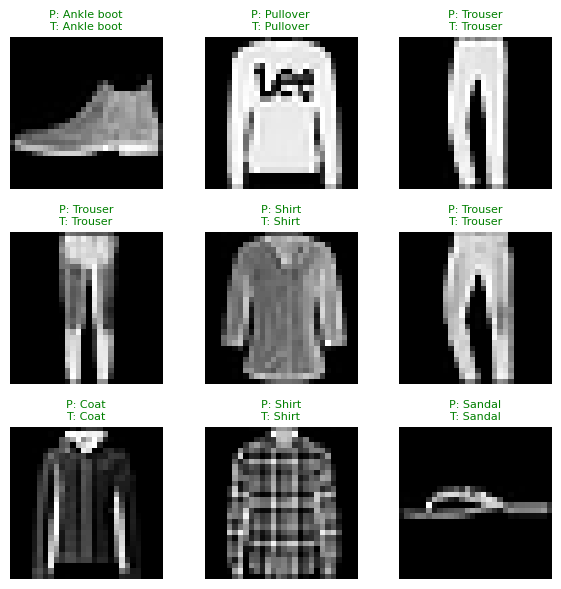

In [12]:
# ---------------------------------------------------
# STEP 8: Prediction ko image ke saath visualize karna
# ---------------------------------------------------
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(test_images[i], cmap='gray')
    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[test_labels[i]]
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"P: {predicted_label}\nT: {true_label}", color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# STEP 7: Prediction karna
# ---------------------------------------------------
predictions = model.predict(test_images)

# Pehli test image ki prediction dekhna
print("Model ka prediction:", class_names[np.argmax(predictions[0])])
print("Asli label:", class_names[test_labels[0]])

# Probability values dekhna (10 classes ki probability)
print("\nSari probabilities:", predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model ka prediction: Ankle boot
Asli label: Ankle boot

Sari probabilities: [1.2193846e-07 1.0389231e-08 9.7320864e-08 1.1557150e-09 1.0048445e-06
 2.1369390e-03 3.6799719e-07 1.9708134e-02 1.3437352e-05 9.7813994e-01]


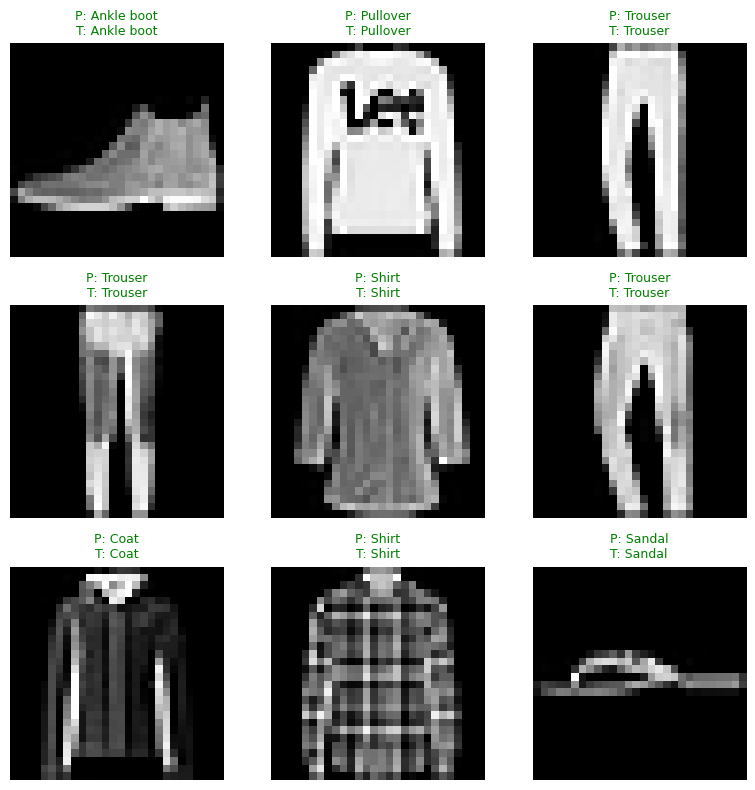

In [15]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# STEP 8: Predictions ko images ke saath dikhana
# ---------------------------------------------------
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(test_images[i], cmap='gray')

    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[test_labels[i]]

    # agar prediction sahi hai to green, warna red
    color = 'green' if predicted_label == true_label else 'red'

    plt.title(f"P: {predicted_label}\nT: {true_label}", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

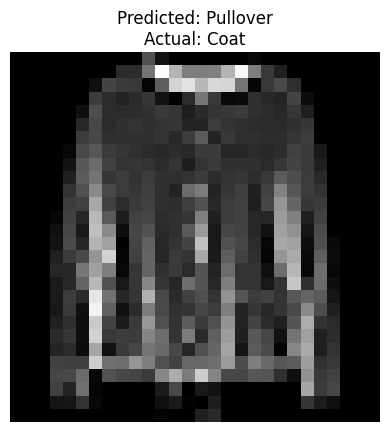

In [16]:
# Kisi bhi index ki image check karna (jaise index 25)
index = 25
plt.imshow(test_images[index], cmap='gray')
plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]}\nActual: {class_names[test_labels[index]]}")
plt.axis('off')
plt.show()

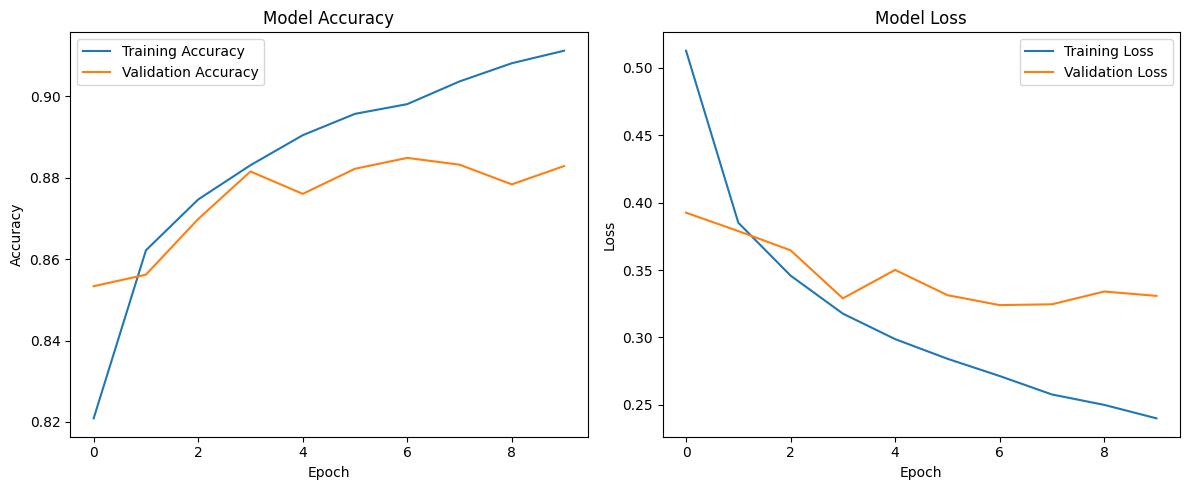

In [18]:


import matplotlib.pyplot as plt

# ---------------------------------------------------
# STEP 9: Training history ka graph banana
# ---------------------------------------------------

# Accuracy ka graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss ka graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_graph.png')   # graph image ki tarah save ho jaega
plt.show()

In [19]:
# ---------------------------------------------------
# STEP 10: Model save karna
# ---------------------------------------------------

# Poora model save karna (architecture + weights + optimizer state)
model.save('fashion_mnist_model.h5')
print("Model save ho gaya: fashion_mnist_model.h5")

# Ya naya recommended format (.keras)
model.save('fashion_mnist_model.keras')
print("Model save ho gaya: fashion_mnist_model.keras")

Model save ho gaya: fashion_mnist_model.h5
Model save ho gaya: fashion_mnist_model.keras
